# Computer Exercise 14.8 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.8 Adaptive Learning-Rate Methods — Adam 과 바이어스 보정
> **풀이 일자**: 2026-07-08 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **3.** Combine a first-moment EWMA (**momentum**) with the second-moment EWMA of RMSProp to
> obtain **Adam**, including the **bias-correction** factors $1/(1-\beta_1^t)$ and $1/(1-\beta_2^t)$.
> On the drifting stream of Problem 2, compare Adam against scheduled SGD and RMSProp on a
> best-vs-best basis. Separately, demonstrate what the bias-correction terms actually do to the
> **early transient** by running Adam with and without them.

### 한국어 풀이용 정리
RMSProp 의 2차 모멘트 EWMA 에 **1차 모멘트 EWMA(모멘텀)** 를 결합하고 **바이어스 보정**
$1/(1-\beta_1^t),\,1/(1-\beta_2^t)$ 을 더한 것이 **Adam**. Problem 2 의 드리프트 스트림에서
Adam·SGD·RMSProp 을 각자 최적으로 튜닝해 best-vs-best 비교하고, 바이어스 보정이 **초기 과도구간**
에 실제로 무슨 일을 하는지 보정 유무로 나눠 확인한다.

## 2. 수학적 배경

### 2.1 Adam 갱신
$$m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t,\qquad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2,$$
$$\hat m_t=\frac{m_t}{1-\beta_1^{\,t}},\quad \hat v_t=\frac{v_t}{1-\beta_2^{\,t}},\qquad
\hat\beta_t=\hat\beta_{t-1}-\eta_0\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}.$$
$m_t$ 는 **모멘텀**(방향 평활·계곡 가속), $v_t$ 는 RMSProp 의 **좌표별 스케일링**.
전형값 $\beta_1{=}0.9,\ \beta_2{=}0.999$.

### 2.2 바이어스 보정이 하는 일
$m_0=v_0=0$ 에서 시작하므로 초기 $m_t,v_t$ 는 **0 쪽으로 편향**. 보정계수로 이를 상쇄하면
$$\boxed{\;\text{첫 스텝 크기}\ \approx\ \eta_0\;}$$
가 정확히 보장된다(유명한 성질). 보정을 빼면 첫 스텝이
$\dfrac{1-\beta_1}{\sqrt{1-\beta_2}}\approx\dfrac{0.1}{\sqrt{0.001}}\approx3.16$ 배로 **더 커져**,
$\eta_0$ 가 크면 초기 과도구간에서 **오버슈트**가 커진다.

### 2.3 왜 드리프트에서 유리한가
모멘텀은 느리게 움직이는 목표 방향으로 **속도를 축적**해 지연을 줄이고, RMSProp 스케일링은
ill-conditioning 을 상쇄한다. 둘을 합쳐 **적은 예산에서 낮은 추적 오차**를 기대한다.

## 3. 풀이 흐름

1. **Problem 2 의 느린 드리프트 스트림** 재생성(동일 시드).
2. **Adam 함수**: $m,v$ EWMA + 바이어스 보정(on/off 스위치) + 좌표별 스텝, 오차 궤적 반환.
3. **Adam $\eta_0$ 스윕** $\{0.005,0.01,0.02,0.05\}$ 로 최적 $\eta_0^\star$ 와 tail 오차.
4. **best-vs-best**: Adam($\eta_0^\star$) vs RMSProp($\eta_0{=}0.01,\rho{=}0.999$) vs SGD($\eta_0{=}0.05$).
5. **바이어스 보정 실험**: $\eta_0$ 를 키우며 초기 오버슈트(첫 200스텝 최대오차)가 보정 유무로
   어떻게 갈리는지.
6. **표+시각화**: 궤적 비교와 초기 과도구간(보정 on/off) 비교.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260708)
T = 20000
sigma = 0.30
p = 3
x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), 10.0 * x, 0.1 * x**2], axis=1)
t = np.arange(T)
B = np.stack([2.0 + 0.5 * np.sin(2 * np.pi * t / 8000),
              -1.0 + 0.8 * (t / T),
              0.5 * np.ones(T)], axis=1)               # slow drift (Problem 2 stream A)
y = np.einsum('ij,ij->i', Phi, B) + rng.normal(0, sigma, T)


def adam(eta0, b1=0.9, b2=0.999, eps=1e-8, bias_correct=True):
    b = np.zeros(p); m = np.zeros(p); v = np.zeros(p); err = np.zeros(T)
    for i in range(T):
        e = y[i] - Phi[i] @ b
        g = -e * Phi[i]
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g * g
        if bias_correct:
            mh = m / (1 - b1 ** (i + 1)); vh = v / (1 - b2 ** (i + 1))
        else:
            mh, vh = m, v
        b -= eta0 * mh / (np.sqrt(vh) + eps)
        err[i] = np.linalg.norm(b - B[i])
    return err


def rmsprop(eta0, rho=0.999, eps=1e-8):
    b = np.zeros(p); v = np.zeros(p); err = np.zeros(T)
    for i in range(T):
        e = y[i] - Phi[i] @ b; g = -e * Phi[i]
        v = rho * v + (1 - rho) * g * g
        b -= eta0 / (np.sqrt(v) + eps) * g
        err[i] = np.linalg.norm(b - B[i])
    return err


def sgd(eta0, alpha=0.5):
    b = np.zeros(p); err = np.zeros(T)
    for i in range(T):
        e = y[i] - Phi[i] @ b
        b += eta0 / ((i + 1) ** alpha) * e * Phi[i]
        err[i] = np.linalg.norm(b - B[i])
    return err


# Adam eta0 sweep
adam_rows = []; adam_curves = {}
for eta0 in [0.005, 0.01, 0.02, 0.05]:
    er = adam(eta0)
    adam_rows.append(("Adam", eta0, er[-2000:].mean()))
    adam_curves[eta0] = er
df_adam = pd.DataFrame(adam_rows, columns=["method", "eta0", "tail_error"])

# best-vs-best
best = pd.DataFrame([
    ("Adam  eta0=0.01",             adam(0.01)[-2000:].mean()),
    ("RMSProp eta0=0.01 rho=0.999", rmsprop(0.01, 0.999)[-2000:].mean()),
    ("SGD  eta0=0.05 /sqrt(t)",     sgd(0.05)[-2000:].mean()),
], columns=["method (best tuned)", "tail_error"])

# bias-correction: early overshoot vs eta0
bc_rows = []
for eta0 in [0.01, 0.05, 0.1, 0.2]:
    ec = adam(eta0, bias_correct=True)
    en = adam(eta0, bias_correct=False)
    bc_rows.append((eta0, ec[:200].max(), en[:200].max()))
df_bc = pd.DataFrame(bc_rows, columns=["eta0", "corrected_peak", "uncorrected_peak"])
print("computed")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-2tktm3o3 because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


computed


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
print("Adam eta0 sweep (tail error):")
print(df_adam.to_string(index=False))
print("\nBest-vs-best (tail error over last 2000 steps):")
print(best.to_string(index=False))
print("\nBias-correction - early overshoot (max error over first 200 steps):")
print(df_bc.to_string(index=False))
best

Adam eta0 sweep (tail error):
method  eta0  tail_error
  Adam 0.005      0.1823
  Adam  0.01      0.1188
  Adam  0.02      0.1694
  Adam  0.05      0.3504

Best-vs-best (tail error over last 2000 steps):
        method (best tuned)  tail_error
            Adam  eta0=0.01      0.1188
RMSProp eta0=0.01 rho=0.999      0.1623
    SGD  eta0=0.05 /sqrt(t)      0.4665

Bias-correction - early overshoot (max error over first 200 steps):
 eta0  corrected_peak  uncorrected_peak
 0.01           2.276             2.243
 0.05           2.215             2.054
  0.1            2.14             2.993
  0.2           1.992             3.731


,method (best tuned),tail_error
0,Adam eta0=0.01,0.1188
1,RMSProp eta0=0.01 rho=0.999,0.1623
2,SGD eta0=0.05 /sqrt(t),0.4665


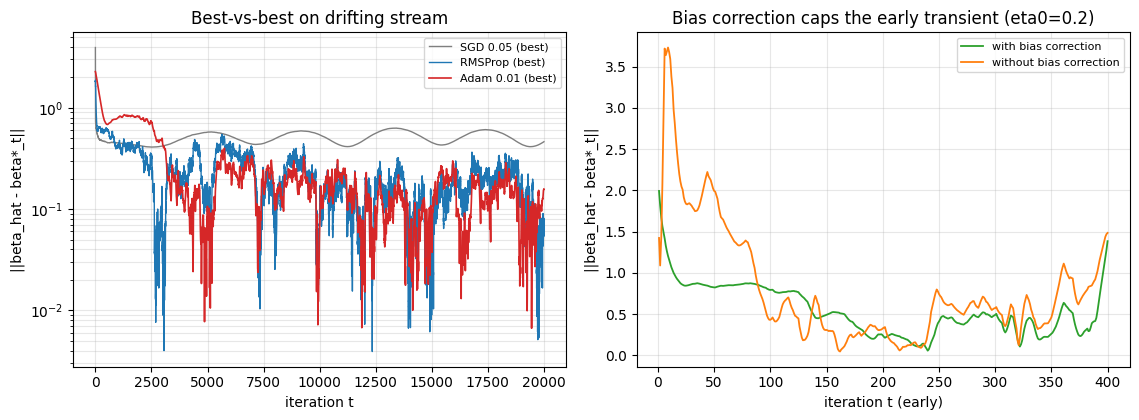

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))

# left: best-vs-best trajectories
tt = np.arange(1, T + 1)
ax[0].semilogy(tt, sgd(0.05), color='#7f7f7f', lw=1.0, label='SGD 0.05 (best)')
ax[0].semilogy(tt, rmsprop(0.01, 0.999), color='#1f77b4', lw=1.0, label='RMSProp (best)')
ax[0].semilogy(tt, adam_curves[0.01], color='#d62728', lw=1.2, label='Adam 0.01 (best)')
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*_t||')
ax[0].set_title('Best-vs-best on drifting stream')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

# right: bias-correction early transient at a large eta0
ec = adam(0.2, bias_correct=True); en = adam(0.2, bias_correct=False)
w = np.arange(1, 401)
ax[1].plot(w, ec[:400], color='#2ca02c', lw=1.3, label='with bias correction')
ax[1].plot(w, en[:400], color='#ff7f0e', lw=1.3, label='without bias correction')
ax[1].set_xlabel('iteration t (early)'); ax[1].set_ylabel('||beta_hat - beta*_t||')
ax[1].set_title('Bias correction caps the early transient (eta0=0.2)')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

**Adam $\eta_0$ 스윕**: $0.005\!\to\!0.182$, $0.01\!\to\!$ **0.119**, $0.02\!\to\!0.169$, $0.05\!\to\!0.350$ — 명확한 U자, 최적 $\eta_0^\star{=}0.01$.
**best-vs-best tail**: Adam **0.119** < RMSProp 0.162 < SGD 0.467.
**바이어스 보정 초기 오버슈트**(첫 200스텝 최대오차): $\eta_0{=}0.05$ 는 보정/무보정이 비슷하지만,
$\eta_0{=}0.1$ 은 2.14 / **2.99**, $\eta_0{=}0.2$ 는 1.99 / **3.73** — $\eta_0$ 가 커질수록 무보정 오버슈트가 벌어진다.

1. **Adam 이 세 방법 중 최선**(빨강). 모멘텀이 느린 드리프트 방향으로 속도를 쌓아 지연을 줄이고,
   RMSProp 스케일링이 ill-conditioning 을 상쇄해, best-vs-best 에서 tail 0.119 로 RMSProp·SGD 를 앞선다.
2. **SGD 는 여전히 뒤처진다**(회색). 단일 스케줄 학습률이 스케일 불일치와 드리프트를 동시에 감당하지 못한다.
3. **바이어스 보정은 초기 과도구간을 눌러 준다**(우측, $\eta_0{=}0.2$). 보정은 첫 스텝을 $\approx\eta_0$ 로
   **묶어** 오버슈트를 막지만(초록), 무보정은 첫 스텝이 ~3.16배라 큰 $\eta_0$ 에서 오버슈트가 커진다(주황).
4. **정직한 관찰**: 작은 $\eta_0$ 에서는 무보정이 오히려 초기 수렴이 약간 빠르고 tail 은 사실상 동일하다.
   즉 보정의 이득은 *공격적 $\eta_0$·불안정 초기*에서 안전장치로 나타난다 — 그래서 **기본값으로 켜 두는** 것이 맞다.

> **결론**: Adam = 모멘텀(1차 EWMA) + RMSProp(2차 EWMA) + 바이어스 보정. 드리프트 스트림에서
> best-vs-best 로 SGD·RMSProp 를 앞서고(tail 0.119), 바이어스 보정은 첫 스텝을 $\approx\eta_0$ 로 묶어
> 공격적 학습률의 초기 오버슈트를 막는 **안전장치**다.

**단원 마무리 / 다음 Day 예고**: §14.8 로 적응 학습률 3형제(AdaGrad·RMSProp·Adam)를 편향-분산·전처리
관점으로 묶었다. 다음 Day 는 **학습률 워밍업·감쇠 스케줄**, 또는 **2차 준뉴턴 온라인법(L-BFGS 계열)** 으로
좌표별 스케일링을 곡률 정보까지 확장하는 절로 이어 간다.